In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from collections import Counter
import ipywidgets as widgets

In [2]:
f = uproot.open("outputs/sparse_sim_run_1.root")
print(f.keys())
edeps_map = f['EdepMap'].to_numpy()

['Hits;1', 'Tracks;1', 'Events;1', 'Pixels;1', 'TotalEdep;1', 'PrimaryEdep;1', 'EdepMap;1', 'EntryMap;1']


In [3]:
pixels = f["Pixels"].arrays(library="np")
edeps_map = np.zeros((352,384))
for event in range(len(pixels['eventID'])):
    evt_mask = pixels['eventID']==event
    px = pixels['pixelX'][evt_mask]
    py = pixels['pixelY'][evt_mask]
    pe = pixels['edep_keV'][evt_mask]
    edeps_map[px, py] += pe

hits_map,_,_ = f['EntryMap'].to_numpy()

(0.0, 50.0)

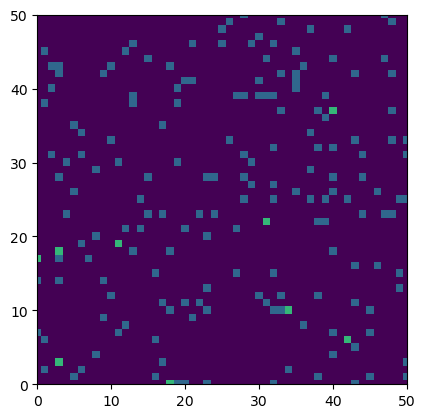

In [4]:
outputs = plt.imshow(hits_map.T, origin='lower', aspect='equal', cmap='viridis')
plt.xlim(0,50)
plt.ylim(0,50)

In [6]:
# Open the output file
#f = uproot.open("build/epix_simulation.root")
f = uproot.open("outputs/sparse_sim_run_1.root")

# ===== Per-event analysis =====
events = f["Events"].arrays(library="np")

print(f"Total events (Electrons): {len(events['eventID'])}")
print(f"Mean total Edep: {np.mean(events['totalEdep_keV']):.2f} keV")
print(f"Mean primary Edep: {np.mean(events['primaryEdep_keV']):.2f} keV")

Total events (Electrons): 10000
Mean total Edep: 175.39 keV
Mean primary Edep: 116.98 keV


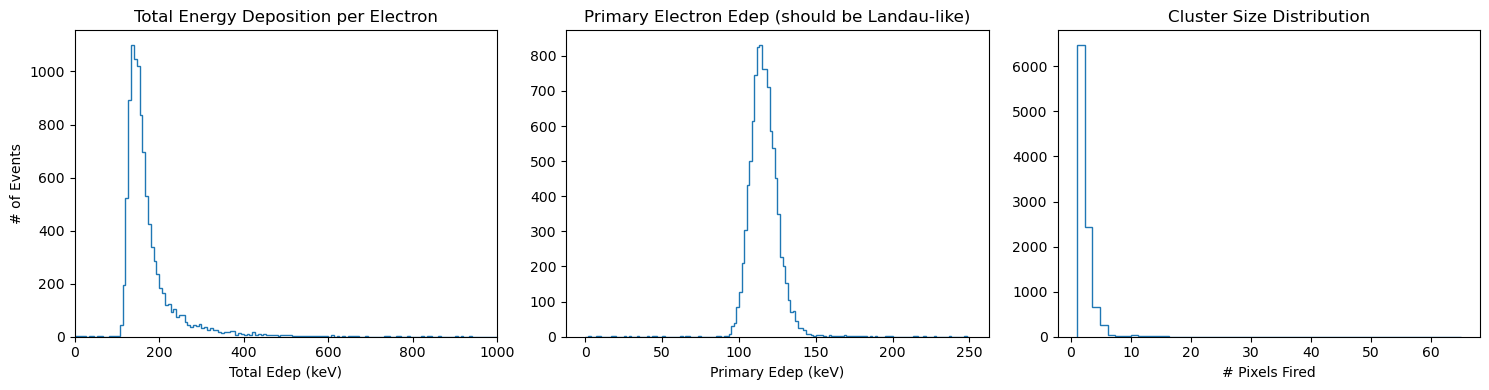

In [7]:
# Energies & Cluster Size Distributions
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(events['totalEdep_keV'], bins=150, range=(0, 1000), histtype='step')
ax[0].set_xlabel("Total Edep (keV)")
ax[0].set_ylabel("# of Events")
ax[0].set_title("Total Energy Deposition per Electron")
ax[0].set_xlim(0,1000)

ax[1].hist(events['primaryEdep_keV'], bins=150, range=(0, 250), histtype='step')
ax[1].set_xlabel("Primary Edep (keV)")
ax[1].set_title("Primary Electron Edep (should be Landau-like)")

ax[2].hist(events['nPixelsFired'], bins=50, histtype='step')
ax[2].set_xlabel("# Pixels Fired")
ax[2].set_title("Cluster Size Distribution")

plt.tight_layout()
plt.savefig("fig/event_summary.png", dpi=150)

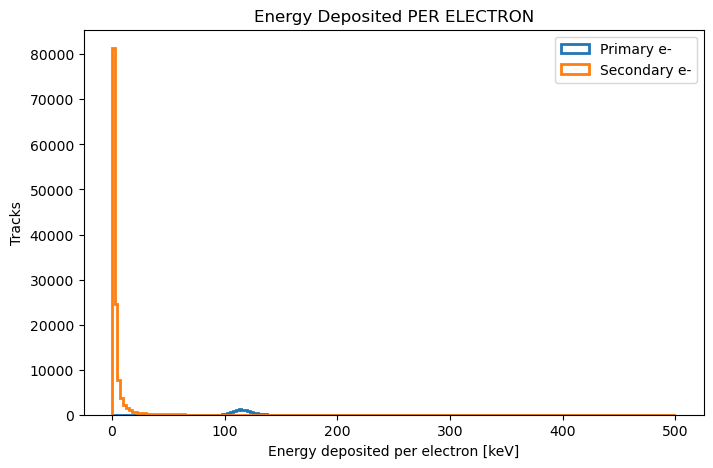

In [8]:
# ===== Per-track analysis: energy per electron =====
tracks = f["Tracks"].arrays(library="np")

# Filter for electrons (pdgCode == 11)
electron_mask = tracks['pdgCode'] == 11
electron_edep = tracks['totalEdep_keV'][electron_mask]
electron_parent = tracks['parentID'][electron_mask]

primary_mask = electron_parent == 0
secondary_mask = electron_parent != 0

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(electron_edep[primary_mask], bins=200, range=(0, 500),
        histtype='step', label='Primary e-', linewidth=2)
ax.hist(electron_edep[secondary_mask], bins=200, range=(0, 500),
        histtype='step', label='Secondary e-', linewidth=2)
ax.set_xlabel("Energy deposited per electron [keV]")
ax.set_ylabel("Tracks")
ax.legend()
ax.set_title("Energy Deposited PER ELECTRON")
plt.savefig("fig/per_electron_edep.png", dpi=150)

In [9]:
import numpy as np
from scipy.ndimage import gaussian_filter

# --- constants (check ePix10k datasheet values for your gain mode) ---
W_SI      = 3.62        # eV per e-h pair
FANO      = 0.128       # Si Fano factor
DIFF_SIGMA_PIX = 0.45   # charge-sharing sigma in *pixel* units (~7 um / 100 um)
READ_NOISE_E   = 420.0   # RMS read noise in electrons (mode-dependent)
GAIN_e_per_ADU = 25.0    # set to your calibration
PEDESTAL_ADU   = 0.0
COMMON_MODE_E  = 10.0   # per-row/col offset RMS (optional)

def digitize(edep_MeV):
    # 1. energy -> mean number of electrons
    N = edep_MeV * 1e6 / W_SI

    # 2. Fano fluctuation (only where signal exists)
    sigma_fano = np.sqrt(np.maximum(FANO * N, 0.0))
    N = np.random.normal(N, sigma_fano)
    N = np.clip(N, 0, None)

    # 3. charge sharing: diffuse the charge to neighbors
    N = gaussian_filter(N, sigma=DIFF_SIGMA_PIX, mode='constant')

    # 4. common-mode (per-row offset), optional
    N += np.random.normal(0, COMMON_MODE_E, size=(N.shape[0], 1))

    # 5. electronic read noise (every pixel, even empty ones)
    N += np.random.normal(0, READ_NOISE_E*1000, size=N.shape)

    # 6. gain + pedestal + quantization -> ADU
    adu = N / GAIN_e_per_ADU + PEDESTAL_ADU
    return np.round(adu).astype(int) / (1e4)

In [10]:
pixels = f["Pixels"].arrays(library="np")
edeps_map = np.zeros((352,384))
for event in range(len(pixels['eventID'])):
    evt_mask = pixels['eventID']==event
    px = pixels['pixelX'][evt_mask]
    py = pixels['pixelY'][evt_mask]
    pe = pixels['edep_keV'][evt_mask]
    edeps_map[px, py] += pe

digi_edeps_map = digitize(edeps_map.T)

digi_edeps_map[digi_edeps_map < 0] = 0

hits_map,_,_ = f['EntryMap'].to_numpy()

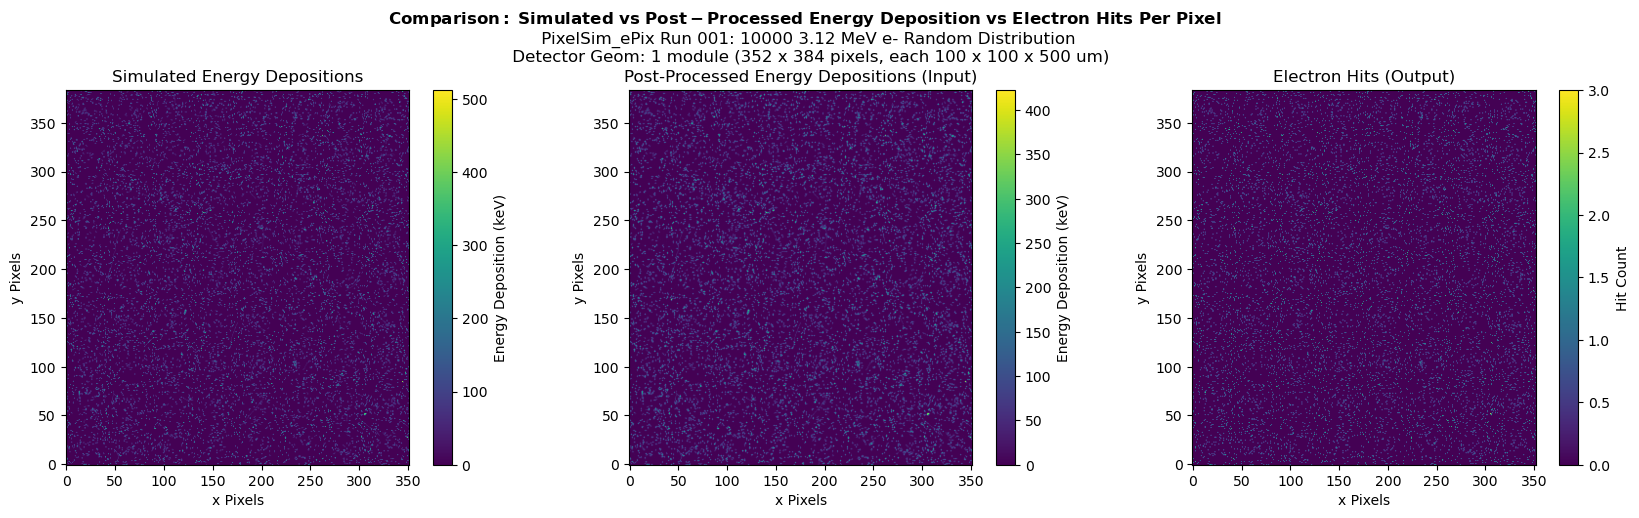

In [20]:
fig,ax=plt.subplots(1,3,figsize=(17,5))

plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n PixelSim_ePix Run 001: {int(np.sum(hits_map))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 x 500 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps_map.T, digi_edeps_map, hits_map.T]

for i in range(3):
    outputs = ax[i].imshow(to_plot[i], origin='lower', aspect='equal', cmap='viridis')
    ax[i].set_title(titles[i])
    ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    ax[i].set_xlabel("x Pixels")
    ax[i].set_ylabel("y Pixels")

plt.tight_layout()
plt.savefig("fig/full_detector_comparison.png", dpi=150);
plt.show()

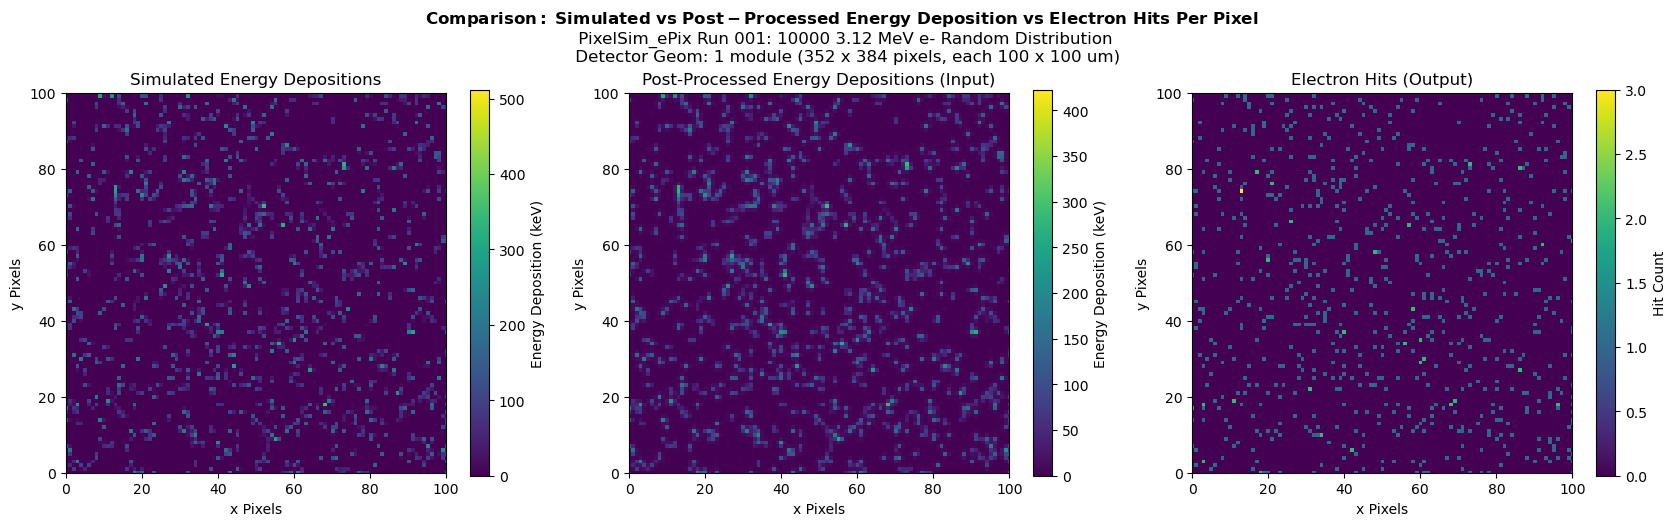

In [21]:
fig,ax=plt.subplots(1,3,figsize=(17,5))

plt.suptitle(r'$\bf{Comparison:\ Simulated\ vs\ Post-Processed\ Energy\ Deposition\ vs\ Electron\ Hits\ Per\ Pixel\ }$' + 
          f" \n PixelSim_ePix Run 001: {int(np.sum(hits_map))} 3.12 MeV e- Random Distribution " + 
          "\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um)");

titles = ["Simulated Energy Depositions","Post-Processed Energy Depositions (Input)","Electron Hits (Output)"]
cbar_labels=["Energy Deposition (keV)","Energy Deposition (keV)","Hit Count"]
to_plot = [edeps_map.T, digi_edeps_map, hits_map.T]

for i in range(3):
    outputs = ax[i].imshow(to_plot[i], origin='lower', aspect='equal', cmap='viridis')
    ax[i].set_title(titles[i])
    ax[i].figure.colorbar(outputs,label=cbar_labels[i],ax=ax[i]);
    ax[i].set_xlim(0,100)
    ax[i].set_ylim(0,100)
    ax[i].set_xlabel("x Pixels")
    ax[i].set_ylabel("y Pixels")

plt.tight_layout()
plt.savefig("fig/100x100_detector_comparison.png", dpi=150);
plt.show()

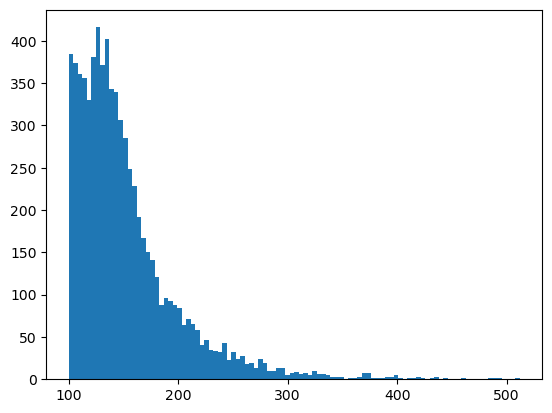

In [30]:
plt.hist(edeps_map[edeps_map>100].flatten(),bins=100);

ValueError: 'explode' must be of length 'x'

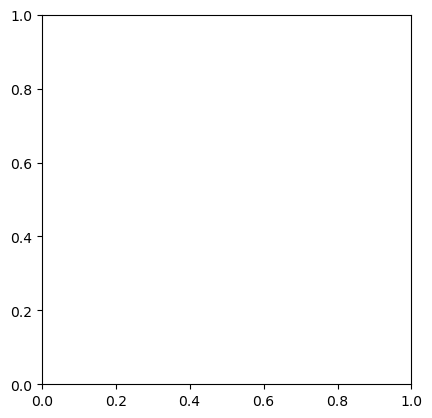

In [22]:
hits_counts = hits_map.flatten()
hits_counts = hits_counts[hits_counts>0]
counts = Counter(hits_counts)

plt.pie(counts.values(), 
        explode=(0.1,0.1), 
        labels=[int(key) for key in counts.keys()], 
        autopct='%1.1f%%', # Format percentages to 1 decimal place
        startangle=140);

plt.title("Relative Abundance of Single/Multi-Electron pixel hits")